In [1]:
from PIL import Image
import numpy as np
import os
import sys

sys.path.append("/home/alberto/UnReflectAnything/")
from utilities.visualization import rgb, panelize
import torch
from dataset.rgbp import HOUSECAT6D_Dataset
from rich import print
%load_ext autoreload
%autoreload 2    


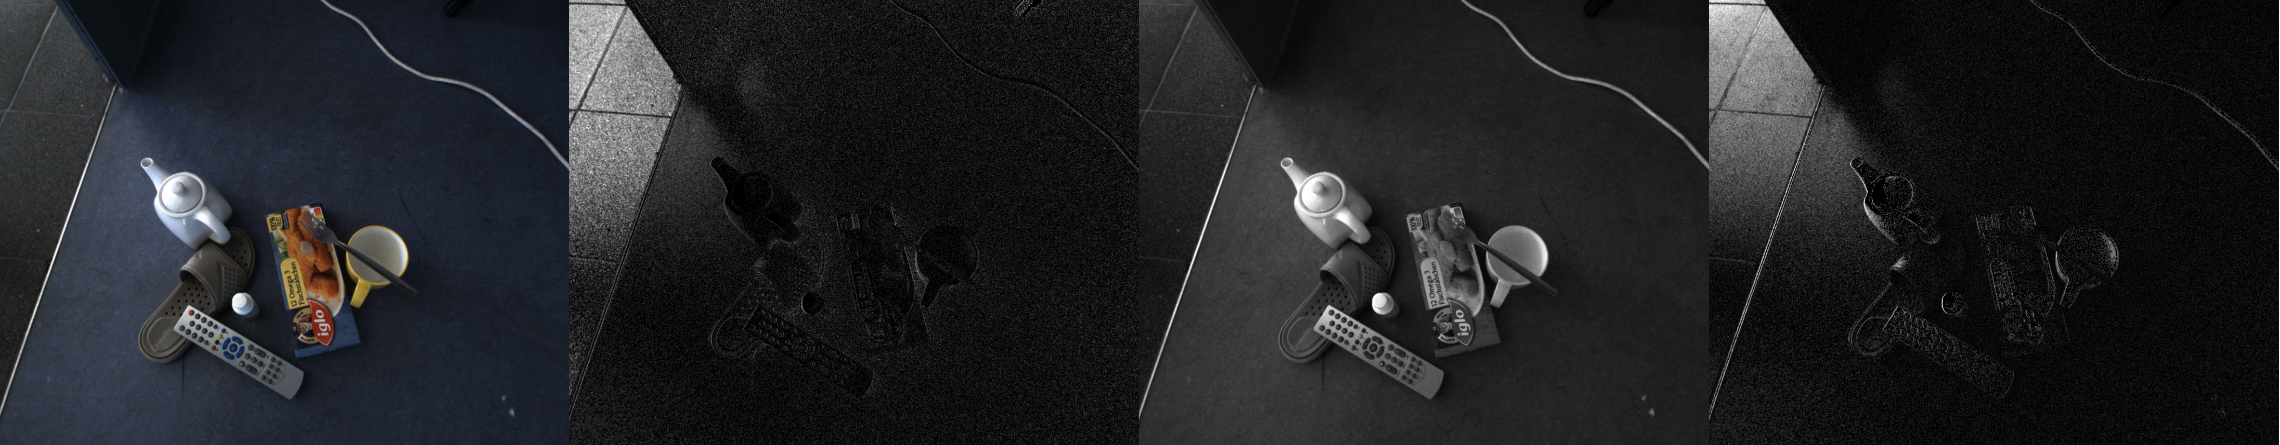

In [2]:
dataset = HOUSECAT6D_Dataset(
    root_dir="/datasets/HouseCat6D/",
    # scene_names=["scene01"],
    rho_s=0.6,
    eps=1e-8,
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break
rgb(
    panelize(
        rgb(batch["rgb"][0], as_tensor=True, resize=(892//2, 1140//2), colormap="gray"),
        rgb(batch["DoP"][0], as_tensor=True, resize=(892//2, 1140//2), colormap="gray"),
        rgb(batch["S0"][0], as_tensor=True, resize=(892//2, 1140//2), colormap="gray"),
        rgb(batch["f_spec"][0], as_tensor=True, resize=(892//2, 1140//2), colormap="gray"),
    )
)

In [3]:
from polar_highlighter import PolarHighlighter
image = batch["rgb"].repeat(4,1,1,1).cuda()
K = batch["intrinsics"].repeat(4,1,1).cuda()
ph = PolarHighlighter().cuda()


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [4]:
depth = ph.compute_depth(image)
image.shape,depth.shape,K.shape

(torch.Size([4, 3, 852, 1096]),
 torch.Size([4, 1, 852, 1096]),
 torch.Size([4, 3, 3]))

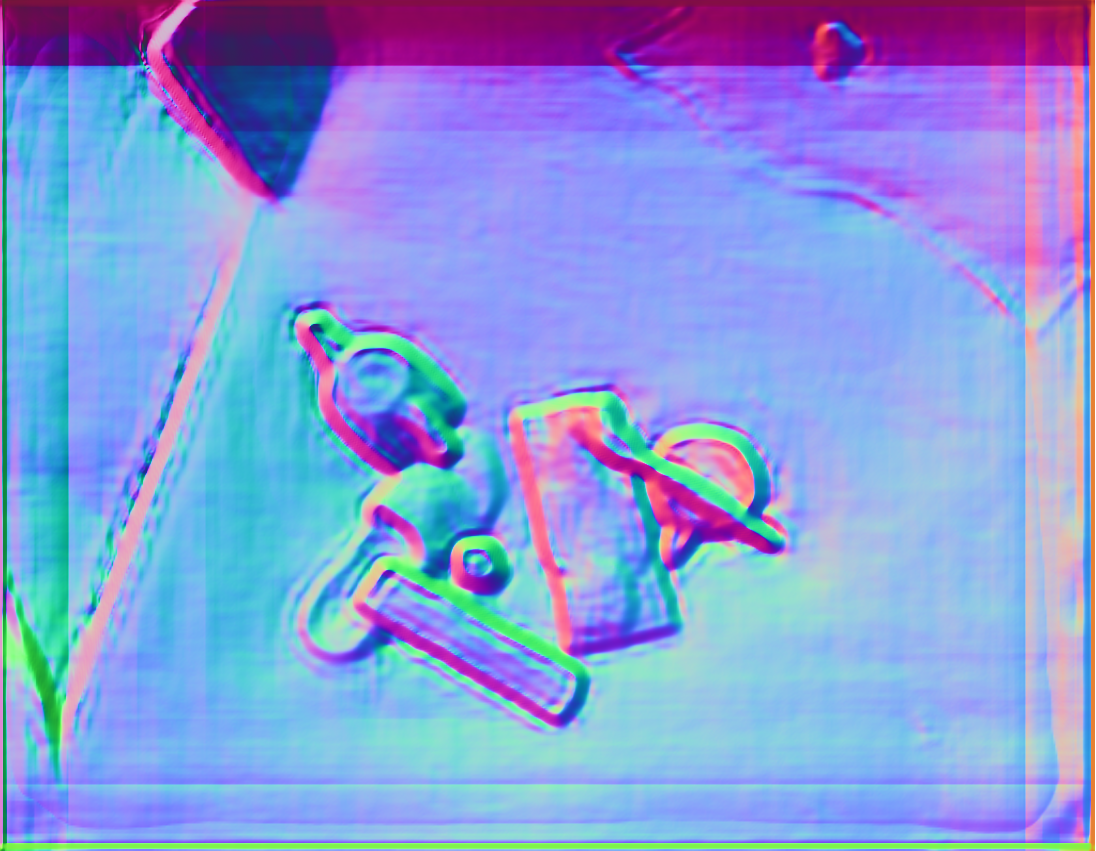

In [5]:
normals = ph.compute_normals(depth,K)
rgb(normals[0],colormap="hsv")

In [18]:
image = batch["rgb"].cuda()
pol = torch.cat([batch["S0"],batch["S1"],batch["S2"]],dim=1).cuda()
intrinsic = batch["intrinsics"].cuda()
image.shape,pol.shape,intrinsic.shape

(torch.Size([1, 3, 852, 1096]),
 torch.Size([1, 3, 852, 1096]),
 torch.Size([1, 3, 3]))

In [19]:
ph = PolarHighlighter().cuda()
result = ph(image,pol,intrinsic)

In [20]:
result["highlight"].shape,image.shape

(torch.Size([1, 1, 852, 1096]), torch.Size([1, 3, 852, 1096]))

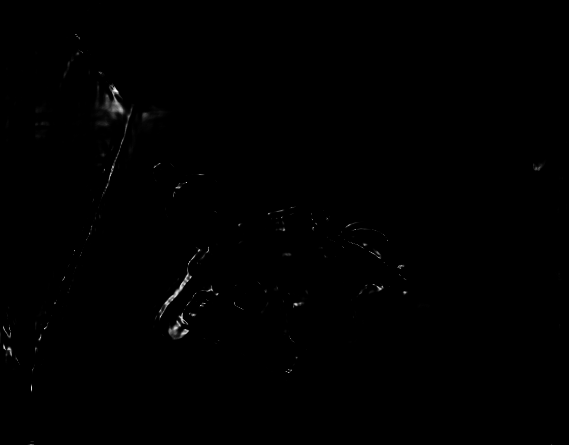

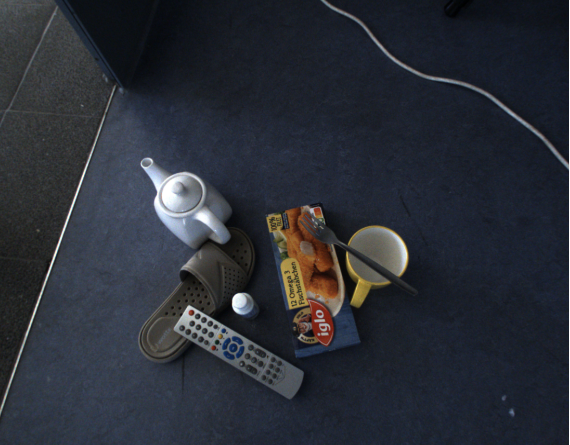

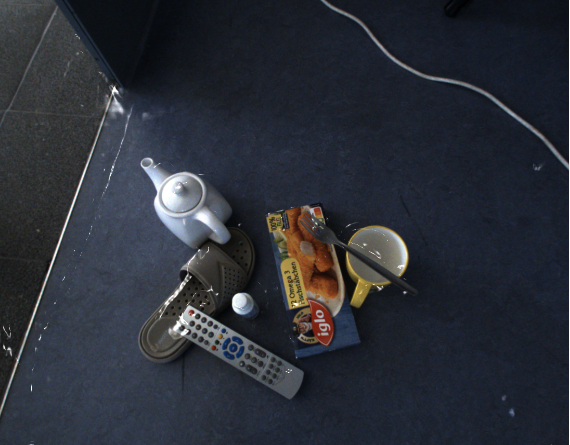

In [22]:
result.keys()
rgb(result["highlight"][0],colormap="gray",resize=(892//2,1140//2))
rgb(image[0],resize=(892//2,1140//2))
rgb(torch.clamp(result["highlight"][0].repeat(3,1,1)+image[0],0.0,1.0),resize=(892//2,1140//2))


In [ ]:
ph.sample_light_source((0,0.5),(-180,180),(0,180))
import rerun as rr
rr.init("polar_highlighter",static=True)
rr.serve_web(web_port=0, grpc_port=torch.randint(10000, 65535, (1,)).item())
rr.log("/3d", rr.ViewCoordinates.RIGHT_HAND_Y_DOWN)


In [ ]:
from utilities import log_rerun_camera
rr.log(
    "/cam",
    rr.Pinhole(
        image_from_camera=K[0].cpu().numpy(),                # (3, 3)
        resolution=(1140,892,),         # (2,)
        camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
    )
)
for i in range(400):
    light_center = ph.sample_light_source((-1,),(-90,90),(-90,0))
    rr.log(
        f"/light_center_{i}",
        rr.Points3D(
            positions=light_center.cpu().numpy().reshape(1, 3),
            colors=light_color.cpu().numpy().reshape(1, 3),
            radii=0.003,
        ),
    )

In [ ]:
rgb(
    panelize(
        rgb(
            batch["rgb"][0],
            as_tensor=True,
            resize=(892, 1140),
            colormap="gray",
        ),
        panelize(
        panelize(
            rgb(
                0.2 * batch["specular"][0] + 0.8 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.4 * batch["specular"][0] + 0.6 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.6 * batch["specular"][0] + 0.4 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.8 * batch["specular"][0] + 0.2 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
        ),
        panelize(
            rgb(
                0.8 * batch["specular"][0] + 0.2 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.6 * batch["specular"][0] + 0.4 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.4 * batch["specular"][0] + 0.6 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.2 * batch["specular"][0] + 0.8 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
        ),
        mode="vertical"),
        resize_to_match=False
    )
)